In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH
from pathlib import Path

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DECODED_DATA_PATH = Path("D:\\common_datasets\\nrem_sc")
UNITS = ['83b', '85b', '116b', '119b']
UNIT = UNITS[0]

sleep_states = nap.load_file(PROCESSED_DATA_PATH / UNIT / "sleep.npz")
session = nap.load_file(PROCESSED_DATA_PATH / UNIT / "sessions_labeled.npz")

(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

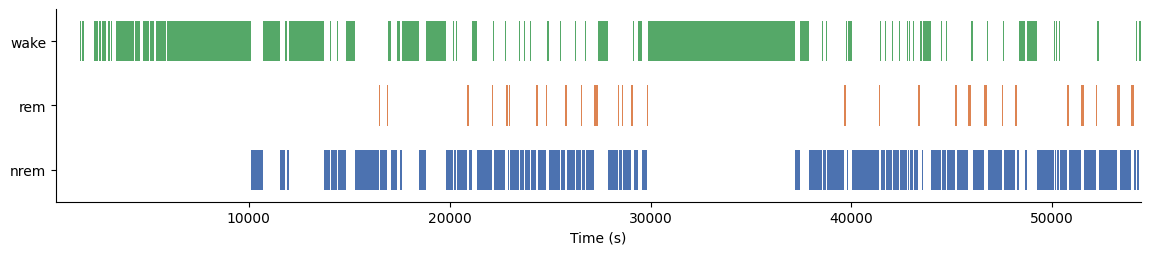

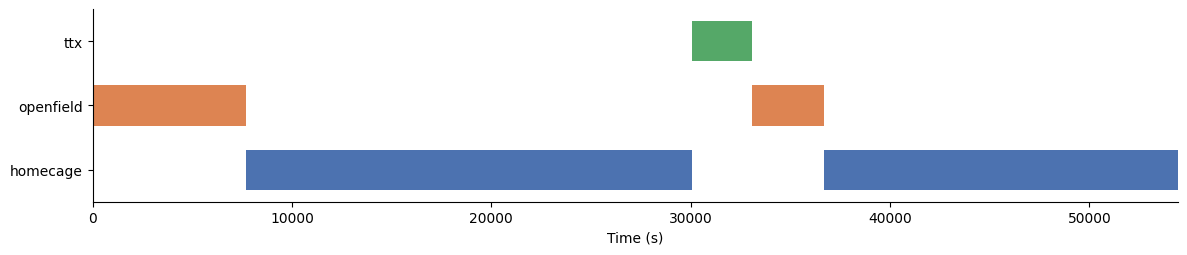

In [28]:
from nrem_sc.utils import plot_intervals

plot_intervals(sleep_states, column='state')
plot_intervals(session, column='label')

### Pre-load and combine the decoded data

In [3]:
def load_decoded(save_dir):
    # Sort files by ending interval time in parent folder 
    paths = sorted(save_dir.rglob("*/position.npz"), key=lambda p: int(re.findall(r'\d+', p.parent.stem)[-2]))
    # Load and concatenate dataframes
    position_dfs = []
    state_dfs = []
    for p in paths:        
        print(f"Loading :{p}")

        pos = nap.load_file(p)
        # Get position bin with highest probability
        position = pos.as_dataframe().idxmax(axis=1).apply(lambda x: pos.metadata['position_bins'][int(x)])
        position_dfs.append(position)
        state_dfs.append(nap.load_file(p.parent / "states.npz").as_dataframe())
    return pd.concat(position_dfs), pd.concat(state_dfs)

pos, states = load_decoded(DECODED_DATA_PATH / UNIT)
nap.TsdFrame(states).save(DECODED_DATA_PATH / UNIT / "states_combined.npz")
nap.Tsd(pos).save(DECODED_DATA_PATH / UNIT / "position_combined.npz")

Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_7699_8199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_8199_8699\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_8699_9199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_9199_9699\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_9699_10199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_10199_10699\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_10699_11199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_11199_11699\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_11699_12199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_12199_12699\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_12699_13199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_13199_13699\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_13699_14199\position.npz
Loading :D:\common_datasets\nrem_sc\83b\pre_ttx_14199_14699\

### Detect sweeps

In [4]:
def extract_sweeps(tdf, label='continuous', min_gap_ms=50):
    epochs = tdf[tdf['state'] == label].find_support(min_gap=min_gap_ms, time_units='ms')
    
    if len(epochs) == 0:
        return pd.DataFrame()

    # Single restrict call for ALL epochs
    all_data = tdf.restrict(epochs)
    pos = all_data['position'].values
    times = all_data.times('s')

    # Assign each sample to its epoch via searchsorted
    starts = epochs['start']
    epoch_idx = np.searchsorted(starts, times, side='right') - 1

    # Split arrays at epoch boundaries
    split_at = np.flatnonzero(np.diff(epoch_idx)) + 1
    pos_chunks = np.split(pos, split_at)
    time_chunks = np.split(times, split_at)

    durations = np.empty(len(pos_chunks))
    net_disp  = np.empty(len(pos_chunks))
    path_len  = np.empty(len(pos_chunks))
    integral  = np.empty(len(pos_chunks))
    n_samples = np.empty(len(pos_chunks), dtype=int)

    for i, (p, t) in enumerate(zip(pos_chunks, time_chunks)):
        uw = np.unwrap(p, period=360)
        durations[i] = t[-1] - t[0]
        net_disp[i]  = np.diff(uw).sum()
        path_len[i]  = np.abs(np.diff(uw)).sum()
        integral[i]  = np.sum(p-p[0])
        n_samples[i] = len(p)

    mask = n_samples >= 2
    return pd.DataFrame({
        'duration': durations[mask],
        'net_displacement': net_disp[mask],
        'path_length': path_len[mask],
        'integral': integral[mask],
        'n_samples': n_samples[mask],
    })

In [5]:
tdf = nap.load_file(DECODED_DATA_PATH / UNIT / "states_combined.npz").as_dataframe()
tdf['position'] = nap.load_file(DECODED_DATA_PATH / UNIT / "position_combined.npz").as_series()
tdf['condition'] = 'pre_ttx'
post_idx = tdf.index > session[session['label'] == 'ttx']['start'].item()
tdf.loc[post_idx, 'condition'] = 'post_ttx'
tdf

,continuous,fragmented,stationary,position,condition
7699.78855,0.391682,0.090109,0.518209,124.498420,pre_ttx
7699.78955,0.392408,0.086776,0.520816,124.498420,pre_ttx
7699.79055,0.392991,0.083743,0.523266,124.498420,pre_ttx
7699.79155,0.393439,0.080994,0.525568,124.498420,pre_ttx
7699.79255,0.393757,0.078513,0.527729,124.498420,pre_ttx
...,...,...,...,...,...
54419.32375,0.100771,0.766308,0.132920,66.499156,post_ttx
54419.32475,0.101274,0.765734,0.132992,66.499156,post_ttx
54419.32575,0.105343,0.757952,0.136704,66.499156,post_ttx
54419.32675,0.109131,0.750736,0.140133,66.499156,post_ttx


In [6]:
threshold = 0.55
dfs = []
for condition in ['pre_ttx', 'post_ttx']:
    data = tdf[tdf['condition'] == condition].copy(deep=True)

    # Determine the state if p>threshold, otherwise 'mixture'
    labels = data[['continuous', 'fragmented', 'stationary']]
    data['state'] = np.where(labels.max(axis=1) > threshold, labels.idxmax(axis=1), 'mixture')

    # Assign sleep state
    data['sleep_state'] = 'unknown'   
    for ep in sleep_states:
        start, end = ep['start'].item(), ep['end'].item()
        if start > data.index[-1]:
            break
        valid = (data.index > start) & (data.index < end)
        data.loc[valid, 'sleep_state'] = ep['state'].item()
    
    # Extract sweeps
    data = nap.TsdFrame(data)
    sweeps = extract_sweeps(data[data['sleep_state'] == 'nrem'], label='continuous', min_gap_ms=50)
    sweeps['condition'] = condition
    sweeps['sleep_state'] = 'nrem'
    dfs.append(sweeps)

sweeps = pd.concat(dfs)

# Partition sweeps into quartiles based on duration
sweeps['quartile'] = pd.qcut(sweeps['duration'], 4, labels=False)
# Compute velocity
sweeps['velocity'] = sweeps['net_displacement']/sweeps['duration']

# Stats
stats = sweeps[sweeps['sleep_state'] == 'nrem']['duration'].describe()
stats

count    18049.000000
mean         0.218096
std          0.164539
min          0.001000
25%          0.100000
50%          0.184000
75%          0.291000
max          1.425000
Name: duration, dtype: float64

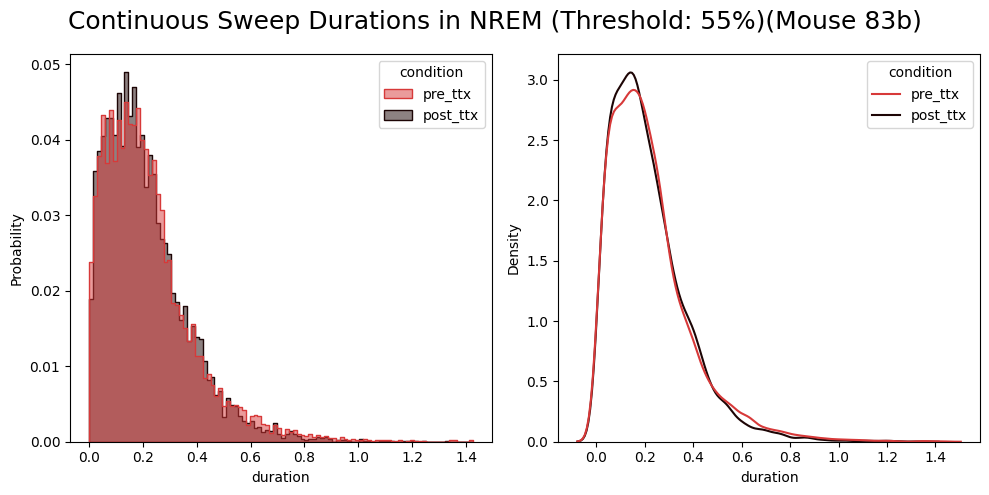

In [10]:
from nrem_sc.constants import INTERIM_DATA_PATH

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
hist_kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)
fig.suptitle(f'Continuous Sweep Durations in NREM (Threshold: {threshold*100:.0f}%)(Mouse {UNIT})', fontsize=18)

axes[0] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', **hist_kwargs, ax=axes[0])
# axes[0].set_xlim(-.1, 1.75)

axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', common_norm=False, palette=palette, ax=axes[1])
# axes[1].set_xlim(-.1, 1.75)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / UNIT / 'figures' / 'nrem_sweep_durations.pdf', format='pdf', dpi=1200)

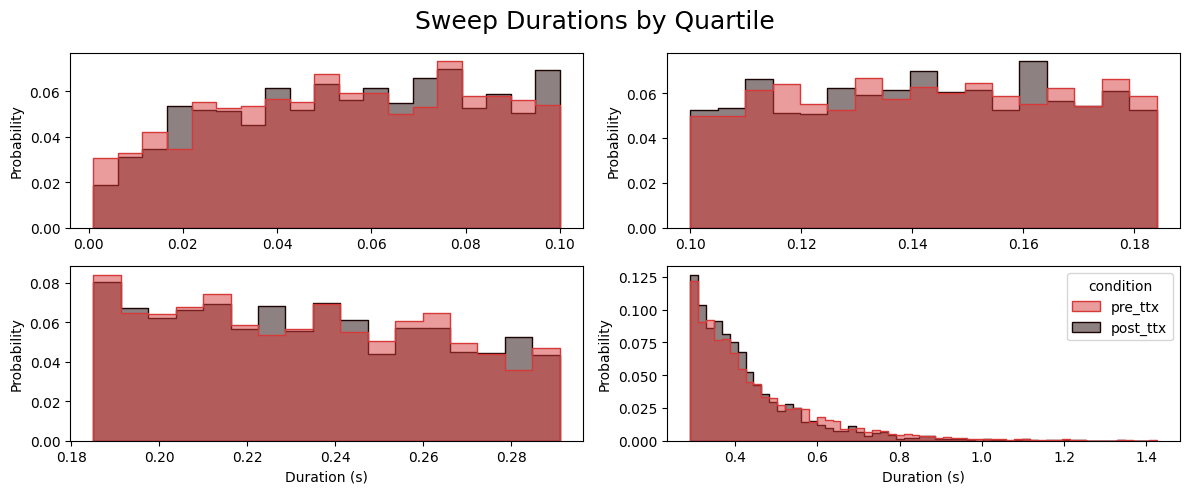

In [8]:
palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle('Sweep Durations by Quartile', fontsize=18)

axes[0, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 0], x='duration', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_xlabel('')

axes[0, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 1], x='duration', hue='condition', **kwargs, ax=axes[0, 1], legend=False)
axes[0, 1].set_xlabel('')

axes[1, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 2], x='duration', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_xlabel('Duration (s)')

axes[1, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 3], x='duration', hue='condition', **kwargs, ax=axes[1, 1], legend=True)
axes[1, 1].set_xlabel('Duration (s)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_durations_quartiles.pdf', format='pdf', dpi=1200)

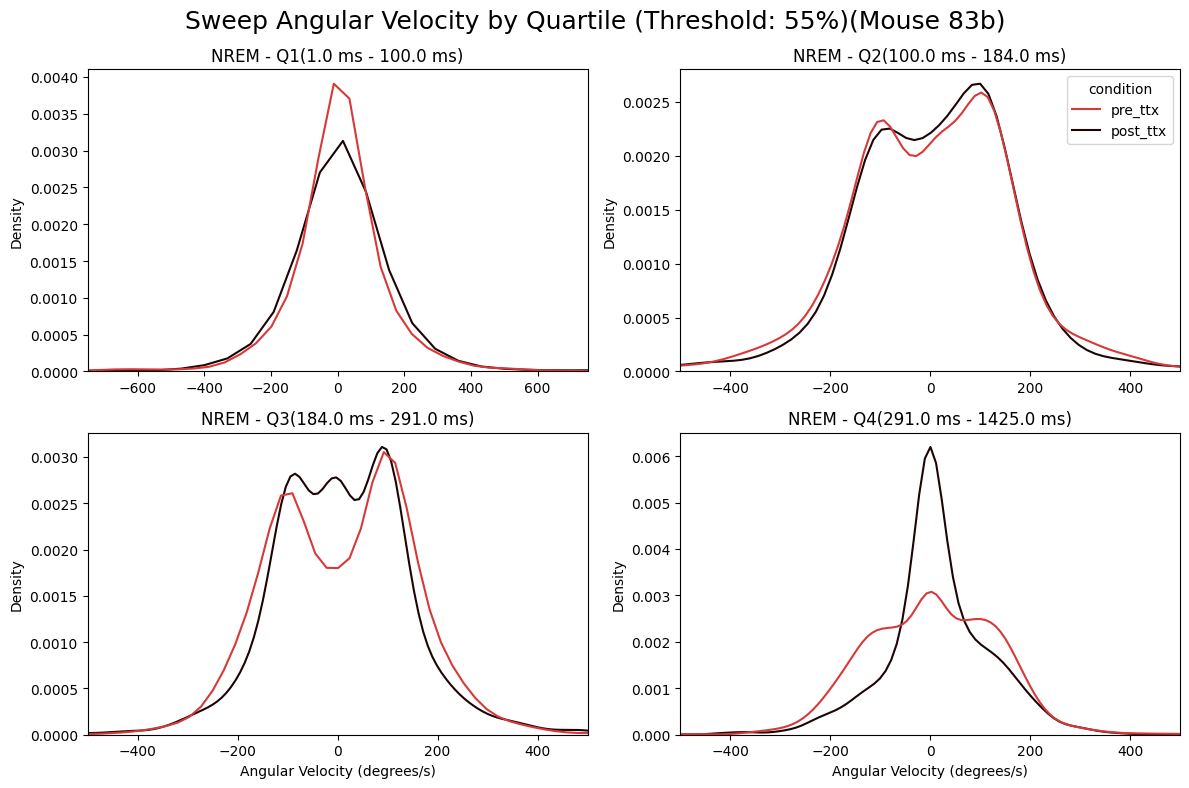

In [11]:

kwargs = dict(common_norm=False, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Sweep Angular Velocity by Quartile (Threshold: {threshold*100:.0f}%)(Mouse {UNIT})', fontsize=18)

axes[0, 0] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 0], x='velocity', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_title(f'NREM - Q1({stats["min"]*1000:.1f} ms - {stats["25%"]*1000:.1f} ms)')
axes[0, 0].set_xlabel('')
axes[0, 0].set_xlim(-750, 750)

axes[0, 1] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 1], x='velocity', hue='condition', **kwargs, ax=axes[0, 1])
axes[0, 1].set_title(f'NREM - Q2({stats["25%"]*1000:.1f} ms - {stats["50%"]*1000:.1f} ms)')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xlim(-500, 500)

axes[1, 0] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 2], x='velocity', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_title(f'NREM - Q3({stats["50%"]*1000:.1f} ms - {stats["75%"]*1000:.1f} ms)')
axes[1, 0].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 0].set_xlim(-500, 500)

axes[1, 1] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 3], x='velocity', hue='condition', **kwargs, ax=axes[1, 1], legend=False)
axes[1, 1].set_title(f'NREM - Q4({stats["75%"]*1000:.1f} ms - {stats["max"]*1000:.1f} ms)')
axes[1, 1].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 1].set_xlim(-500, 500)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / UNIT / 'figures' / 'sweep_angular_velocity_quartiles_kde.pdf', format='pdf', dpi=1200)

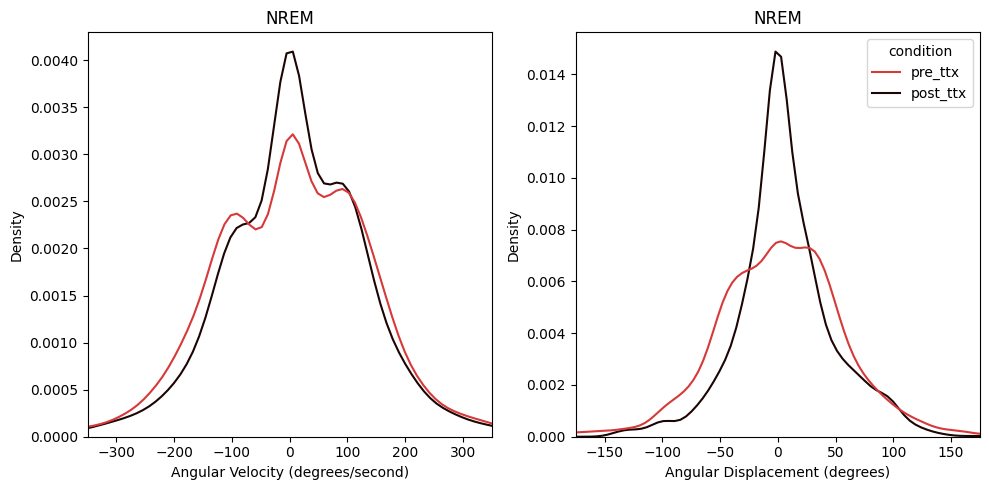

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(common_norm=False, palette=palette)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['velocity'].abs() < 1000
axes[0] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'nrem'][mask]), x='velocity', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-350, 350)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['duration'].abs() > 0.25
axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'][mask], x='net_displacement', hue='condition', **kwargs, ax=axes[1])
axes[1].set_title('NREM')
axes[1].set_xlabel('Angular Displacement (degrees)')
axes[1].set_xlim(-175, 175)


# axes[1] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'rem']), x='velocity', hue='condition', **kwargs, ax=axes[1], legend=True)
# axes[1].set_title('REM')
# axes[1].set_xlabel('Angular Velocity (degrees/second)')
# axes[1].set_xlim(-350, 350)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_kde.pdf', format='pdf', dpi=1200)

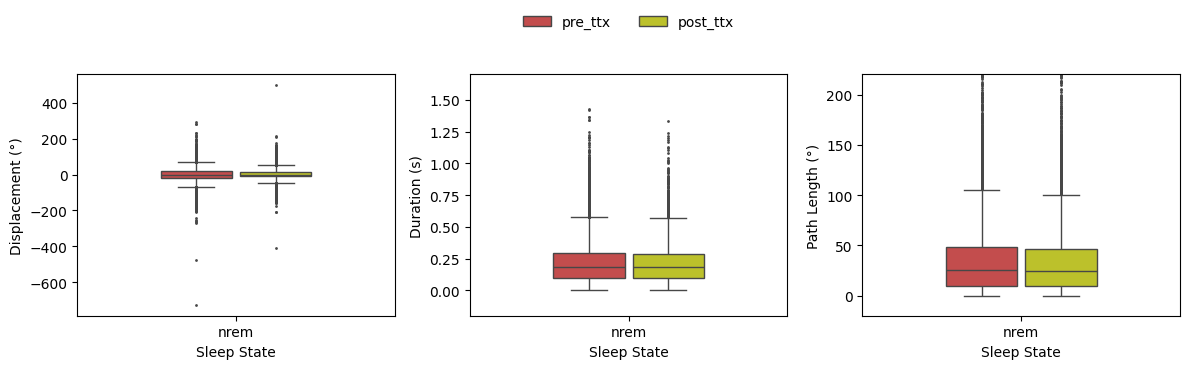

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
palette = ["#d73939", "#d3da12ff"]
box_kwargs = dict(fliersize=1, width=0.5, palette=palette, gap=0.1)

# fig.suptitle('Sweep Metrics by Sleep State', fontsize=18)

axes[0] = sns.boxplot(data=sweeps, x='sleep_state', y='net_displacement', hue='condition', **box_kwargs, ax=axes[0], legend=False)
# axes[0].set_ylim(-150, 150)
axes[0].set_ylabel('Displacement (°)')
axes[0].set_xlabel('Sleep State')

axes[1] = sns.boxplot(data=sweeps, x='sleep_state', y='duration', hue='condition', **box_kwargs, ax=axes[1])
axes[1].set_ylabel('Duration (s)')
axes[1].set_xlabel('Sleep State')
axes[1].set_ylim(-0.2, 1.7)

sns.move_legend(axes[1], "upper center", bbox_to_anchor=(0.5, 1.3),  ncol=3, title=None, frameon=False)

axes[2] = sns.boxplot(data=sweeps, x='sleep_state', y='path_length', hue='condition', **box_kwargs, ax=axes[2], legend=False)
axes[2].set_ylabel('Path Length (°)')
axes[2].set_xlabel('Sleep State')
axes[2].set_ylim(-20, 220)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_boxplots.pdf', format='pdf', dpi=1200)